# Customer Segmentation for Credit Card Customers

**Dataset:** Credit Card Customer Segmentation
**Type:** Unsupervised Learning  
**Objective:** Explore, preprocess, cluster, and derive business insights from credit card customer data.

---

## Project Phases
1. Data Exploration & Preprocessing
2. Determining Optimal Number of Clusters
3. Customer Segmentation
4. Visualization & Analysis
5. Business Insights & Recommendations

# Data Exploration

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('CC GENERAL.csv')
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.info()
print("\nBasic stats:")
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


**Check for missing values** 

In [22]:
print("Missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64


**Drop that one missing values in credit limit**

In [23]:
df = df.dropna(subset=['CREDIT_LIMIT'])

**Investigate why minimum payments are missing**

**1-Start by visualizing the distributions**

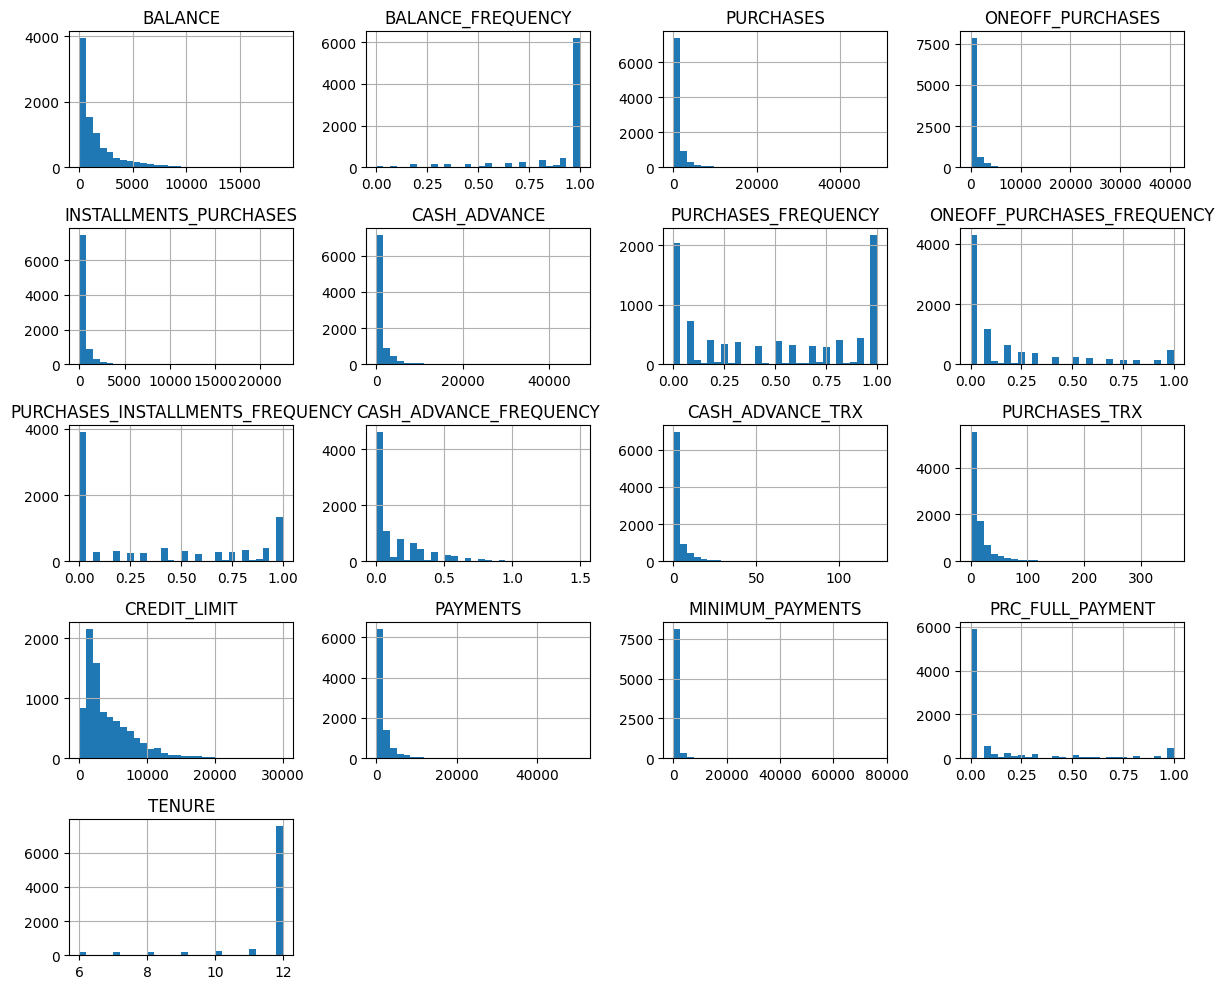

In [24]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

In [25]:
print("\nSkewness of each numeric column:")
print(df.select_dtypes(include=np.number).skew().sort_values(ascending=False))


Skewness of each numeric column:
MINIMUM_PAYMENTS                    13.622193
ONEOFF_PURCHASES                    10.044622
PURCHASES                            8.143969
INSTALLMENTS_PURCHASES               7.298823
PAYMENTS                             5.907465
CASH_ADVANCE_TRX                     5.720976
CASH_ADVANCE                         5.166323
PURCHASES_TRX                        4.630493
BALANCE                              2.393270
PRC_FULL_PAYMENT                     1.942641
CASH_ADVANCE_FREQUENCY               1.828644
ONEOFF_PURCHASES_FREQUENCY           1.535453
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509023
PURCHASES_FREQUENCY                  0.059970
BALANCE_FREQUENCY                   -2.024193
TENURE                              -2.944788
dtype: float64


**Minimum payments represent amount the customer must pay that month**

**Multiple options could be the case**

1-Customer didn't use the credit card -> no balance -> no payment

2-Balance is 0 

3-Account is inactive

**Test each hypothesis**

In [27]:
missing = df[df['MINIMUM_PAYMENTS'].isna()]
not_missing = df[df['MINIMUM_PAYMENTS'].notna()]

In [28]:
missing[['PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES']].describe()

,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES
count,313.000000,313.000000,313.000000
mean,393.087284,250.433387,142.653898
std,757.905701,624.453991,311.289043
min,0.000000,0.000000,0.000000
25%,1.400000,0.000000,0.000000
50%,130.400000,0.000000,0.000000
75%,399.950000,176.030000,152.280000
max,7597.090000,6761.290000,2959.240000


In [32]:
((missing['PURCHASES'] == 0) | (missing['PURCHASES'].isna())).sum()

np.int64(76)

**Since that they're all not close to zero hypothesis is weak**

In [30]:
missing['BALANCE'].describe()

count     313.000000
mean      555.441321
std      1292.687887
min         0.000000
25%         0.187069
50%        16.848358
75%       286.686616
max      9164.724752
Name: BALANCE, dtype: float64

In [33]:
(missing['BALANCE'] == 0).mean() * 100

np.float64(23.642172523961662)

**Can be true since that 25% of the data is almost zero and median is a very small number**

In [34]:
missing[['PURCHASES', 'BALANCE', 'CASH_ADVANCE', 'TENURE']].describe()

,PURCHASES,BALANCE,CASH_ADVANCE,TENURE
count,313.000000,313.000000,313.000000,313.000000
mean,393.087284,555.441321,559.136698,11.063898
std,757.905701,1292.687887,1185.132567,1.869734
min,0.000000,0.000000,0.000000,6.000000
25%,1.400000,0.187069,0.000000,12.000000
50%,130.400000,16.848358,0.000000,12.000000
75%,399.950000,286.686616,480.104401,12.000000
max,7597.090000,9164.724752,7616.064965,12.000000


In [35]:
df.groupby(df['MINIMUM_PAYMENTS'].isna())[['PURCHASES', 'BALANCE', 'CASH_ADVANCE']].mean()

,PURCHASES,BALANCE,CASH_ADVANCE
MINIMUM_PAYMENTS,,,
False,1025.433874,1601.224893,994.175523
True,393.087284,555.441321,559.136698


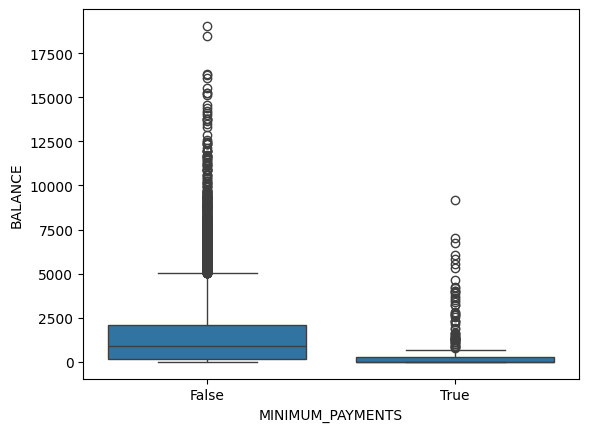

In [36]:
sns.boxplot(x=df['MINIMUM_PAYMENTS'].isna(), y=df['BALANCE'])
plt.show()

**This shows that customers with minimum payment missing are less inactive but not completly inactive :** 

Spend much less (393 vs 1025)

Have lower balance (555 vs 1601)

Take less cash advance (559 vs 994)

**Missing minimum payments are strongly associated with low balance levels, suggesting that customers who carry little or no debt are less likely to have a recorded minimum payment.**

**Most of these missing-minimum-payment customers do NOT use these optional credit features.**

Half of them never take cash advances.

Half never do one-off or installment purchases.

**Behavioral insight:**

Missing MINIMUM_PAYMENTS tends to occur for low-activity customers in these categories.

It reinforces what we already found: these are low-balance, low-usage customers, not fully inactive, but mostly conservative users.

**Why it aligns with balance:**

If you aren’t using optional purchases and your balance is low → there’s no minimum payment generated, hence the missing values.

These zeros in optional features are part of the same behavioral pattern causing missing minimum payments.

**For customers with missing MINIMUM_PAYMENTS, most have low balances and minimal optional purchases, so the missing values are not random and will be imputed with 0.**

In [46]:
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(0)

**Checking for skewness**

In [38]:
skewness = df.select_dtypes(include=np.number).skew().sort_values(ascending=False)
print(skewness)

MINIMUM_PAYMENTS                    13.807831
ONEOFF_PURCHASES                    10.044622
PURCHASES                            8.143969
INSTALLMENTS_PURCHASES               7.298823
PAYMENTS                             5.907465
CASH_ADVANCE_TRX                     5.720976
CASH_ADVANCE                         5.166323
PURCHASES_TRX                        4.630493
BALANCE                              2.393270
PRC_FULL_PAYMENT                     1.942641
CASH_ADVANCE_FREQUENCY               1.828644
ONEOFF_PURCHASES_FREQUENCY           1.535453
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509023
PURCHASES_FREQUENCY                  0.059970
BALANCE_FREQUENCY                   -2.024193
TENURE                              -2.944788
dtype: float64


**Data is heavily right skewed, applying log transform on the heavily skewed data**

In [39]:
cols_to_transform = [
    'MINIMUM_PAYMENTS', 'ONEOFF_PURCHASES', 'PURCHASES', 
    'INSTALLMENTS_PURCHASES', 'PAYMENTS', 'CASH_ADVANCE_TRX',
    'CASH_ADVANCE', 'PURCHASES_TRX', 'BALANCE', 
    'PRC_FULL_PAYMENT', 'CASH_ADVANCE_FREQUENCY',
    'ONEOFF_PURCHASES_FREQUENCY', 'CREDIT_LIMIT'
]

for col in cols_to_transform:
    df[col] = np.log1p(df[col])

print(df.select_dtypes(include=np.number).skew().sort_values(ascending=False))

PRC_FULL_PAYMENT                    1.745872
CASH_ADVANCE_FREQUENCY              1.455482
ONEOFF_PURCHASES_FREQUENCY          1.290460
CASH_ADVANCE_TRX                    0.940039
PURCHASES_INSTALLMENTS_FREQUENCY    0.509023
CASH_ADVANCE                        0.262755
ONEOFF_PURCHASES                    0.185650
PURCHASES_FREQUENCY                 0.059970
PURCHASES_TRX                       0.032536
INSTALLMENTS_PURCHASES             -0.025206
CREDIT_LIMIT                       -0.101438
PURCHASES                          -0.764844
BALANCE                            -0.861421
MINIMUM_PAYMENTS                   -1.292368
PAYMENTS                           -1.779084
BALANCE_FREQUENCY                  -2.024193
TENURE                             -2.944788
dtype: float64


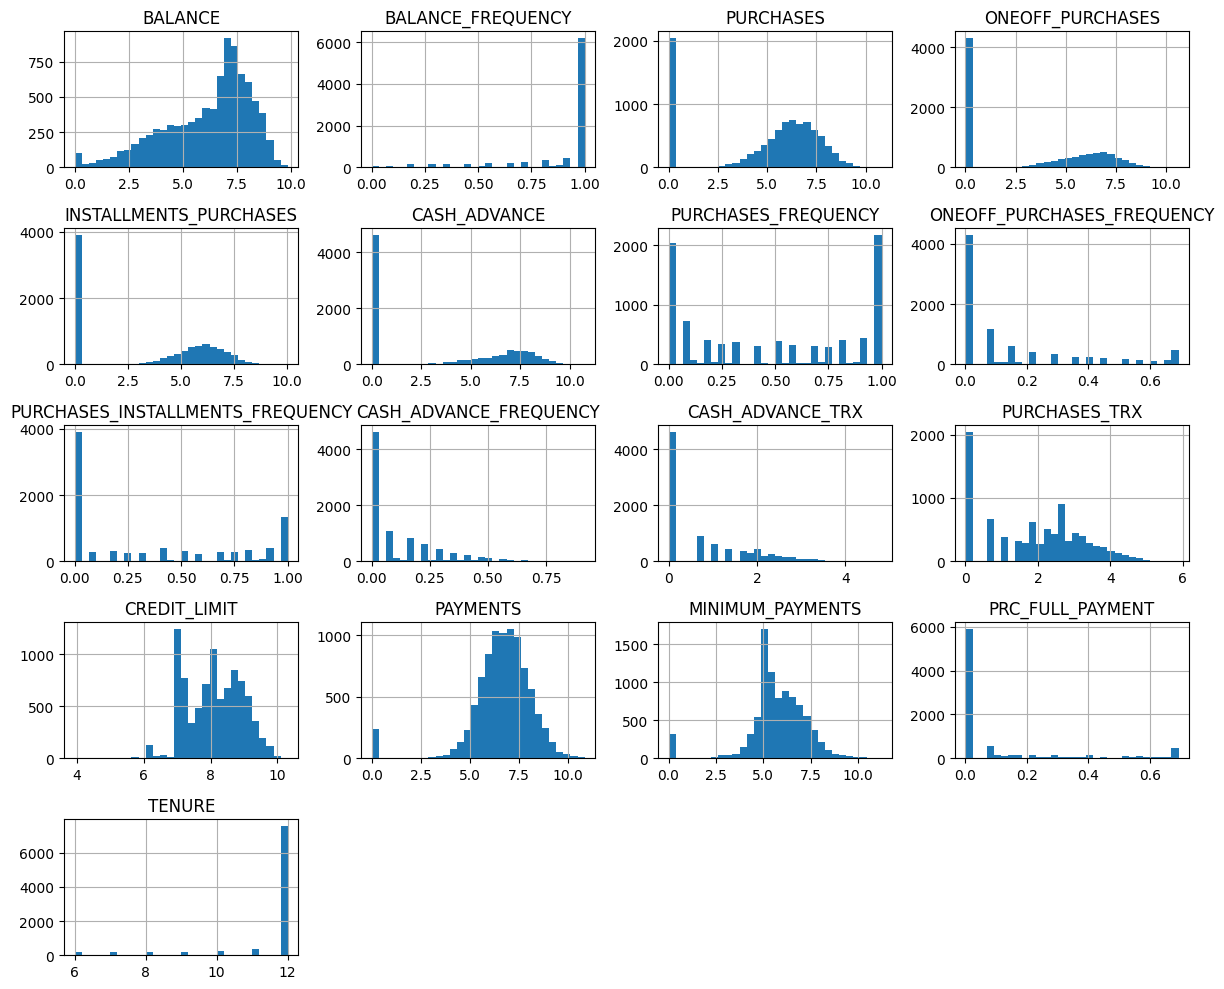

In [40]:
df.hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

**Applied log transform on the data so that we can use GMM since that they assume data are normally disstributed and for k-means as its calculating based on euclidean distance**

In [42]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.drop(columns=['CUST_ID'])

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns)


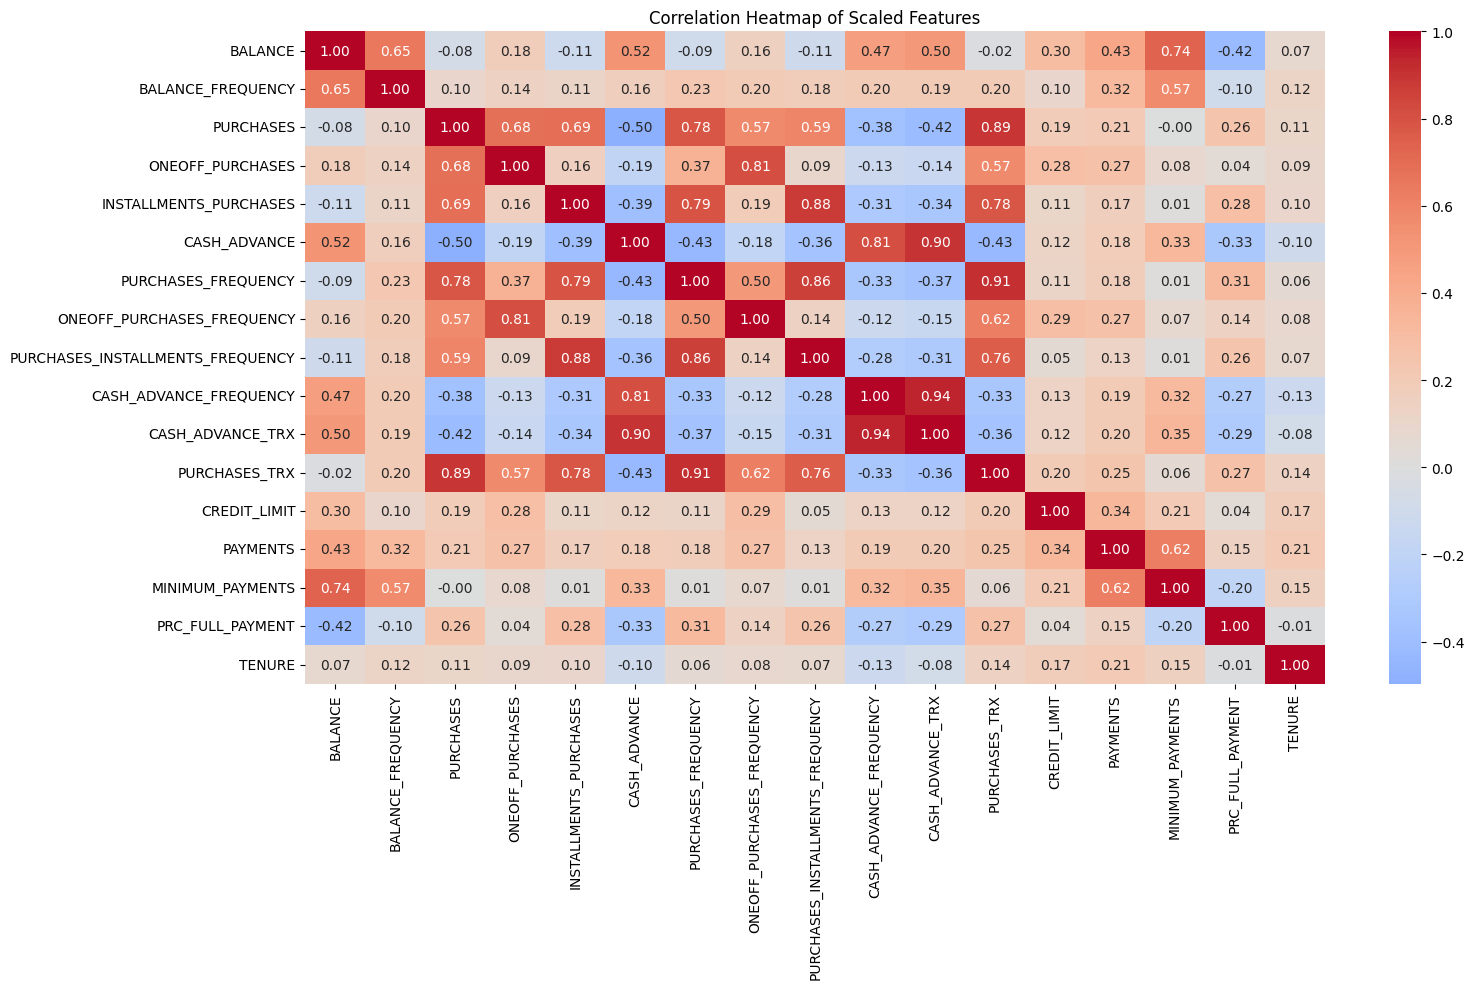

In [43]:
plt.figure(figsize=(16, 10))
sns.heatmap(df_scaled.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Scaled Features')
plt.tight_layout()
plt.show()

**Strong Positive Correlations (features moving together)**

CASH_ADVANCE_FREQUENCY & CASH_ADVANCE_TRX → 0.94 — almost identical information. These two are nearly redundant.

PURCHASES_FREQUENCY & PURCHASES_TRX → 0.91 — same story, how often you purchase and how many transactions are nearly the same thing.

PURCHASES & PURCHASES_TRX → 0.89 — more purchases = more transactions, makes complete sense.

INSTALLMENTS_PURCHASES & PURCHASES_INSTALLMENTS_FREQUENCY → 0.88 — redundant pair.

BALANCE & MINIMUM_PAYMENTS → 0.74 — higher balance means higher minimum payment obligation, very logical.

CASH_ADVANCE & CASH_ADVANCE_FREQUENCY → 0.81 — another near-redundant cash advance pair.

**Strong Negative Correlations (opposite behaviors)**

PURCHASES & CASH_ADVANCE → -0.50 — this is behaviorally meaningful. Customers who make purchases tend NOT to take cash advances and vice versa. These are two distinct customer types.

BALANCE & PRC_FULL_PAYMENT → -0.42 — customers who pay in full carry lower balances. Logical and expected.

CASH_ADVANCE & PURCHASES_FREQUENCY → -0.43 — cash advance users shop less frequently.

**Business Insight**
The heatmap is essentially revealing two distinct behavioral axes in your data already, before any clustering:

A purchaser axis — high purchases, high frequency, high transactions
A cash advance axis — high cash advance, high cash advance frequency, high balance

These two groups are negatively correlated with each other, meaning they're likely to become separate clusters.

**Start clustering**

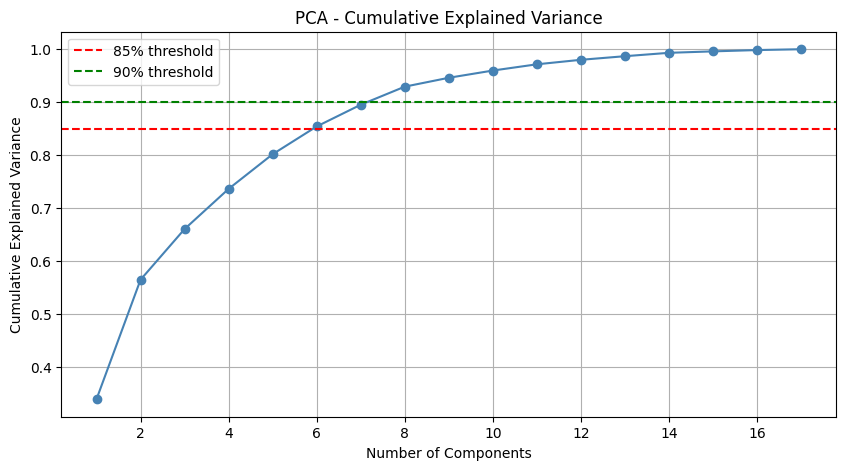

[0.33988956 0.5652422  0.66083665 0.73659402 0.80197552 0.85430183
 0.89528417 0.92938364 0.94614376 0.95977445 0.9715346  0.98004563
 0.98683618 0.99321734 0.99595635 0.99838981 1.        ]


In [57]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(df_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', color='steelblue')
plt.axhline(y=0.85, color='red', linestyle='--', label='85% threshold')
plt.axhline(y=0.90, color='green', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

print(explained_variance)

In [58]:
pca = PCA(n_components=7)
df_pca = pca.fit_transform(df_scaled)

print("Shape after PCA:", df_pca.shape)
print("Variance explained:", np.sum(pca.explained_variance_ratio_).round(3))

Shape after PCA: (8949, 7)
Variance explained: 0.895


c:\Users\hazem\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


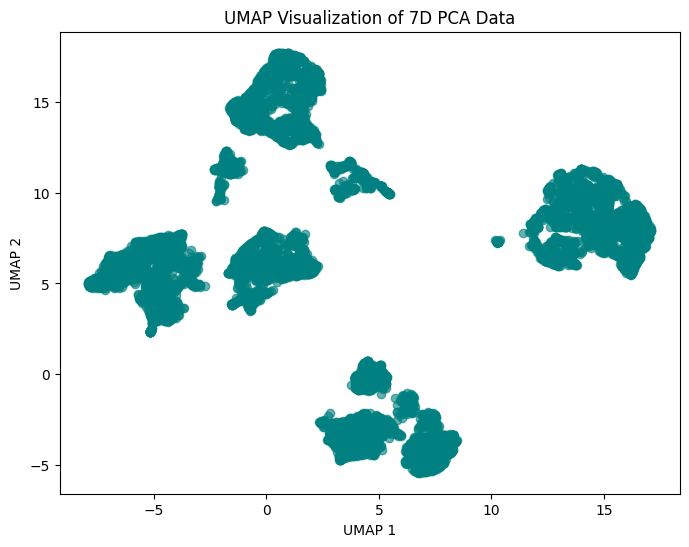

In [ ]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
df_umap = reducer.fit_transform(df_pca)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df_umap[:,0], df_umap[:,1], alpha=0.6, c='teal')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Visualization of 7D PCA Data')
plt.show()

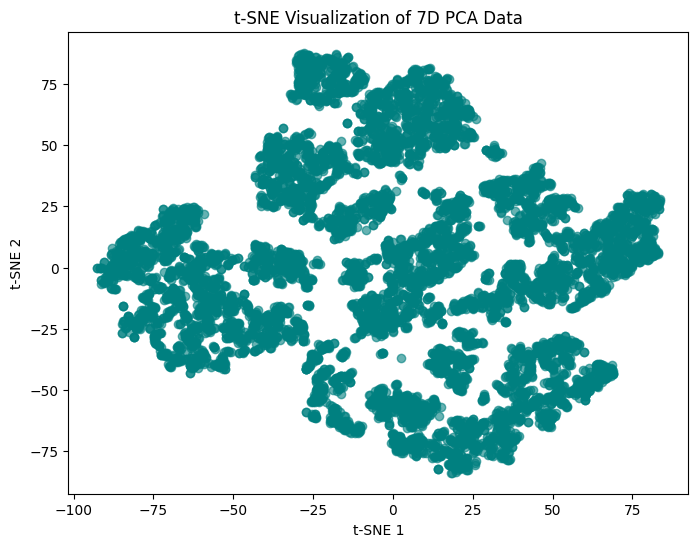

In [91]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
df_tsne = tsne.fit_transform(df_pca)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df_tsne[:,0], df_tsne[:,1], alpha=0.6, c='teal')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Visualization of 7D PCA Data')
plt.show()

**Find optimal K**

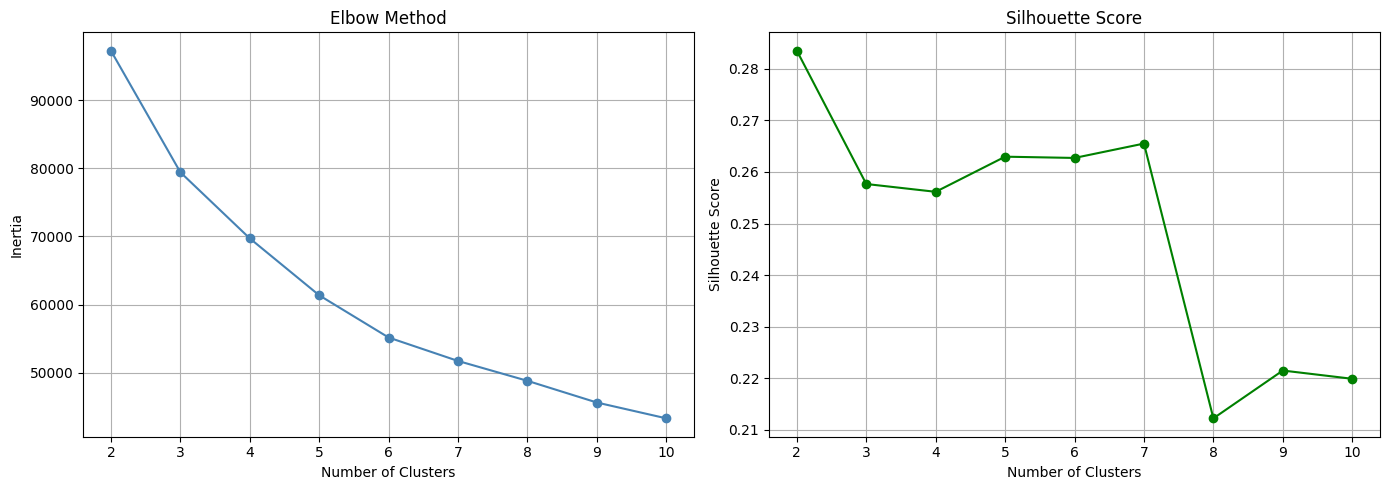


Silhouette Scores:
  k=2: 0.2835
  k=3: 0.2577
  k=4: 0.2562
  k=5: 0.2630
  k=6: 0.2627
  k=7: 0.2655
  k=8: 0.2122
  k=9: 0.2215
  k=10: 0.2199


In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(df_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia, marker='o', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(K_range, silhouette, marker='o', color='green')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nSilhouette Scores:")
for k, s in zip(K_range, silhouette):
    print(f"  k={k}: {s:.4f}")

**Not sure 4 or 6**

In [60]:
for k in [4, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)
    df[f'Cluster_k{k}'] = labels
    print(f"\nk={k} cluster sizes:")
    print(pd.Series(labels).value_counts().sort_index())


k=4 cluster sizes:
0    2107
1    2652
2    1430
3    2760
Name: count, dtype: int64

k=6 cluster sizes:
0    1839
1    2270
2    1420
3    1386
4    1249
5     785
Name: count, dtype: int64


k=4 cluster sizes: 2107, 2652, 1430, 2760 — beautifully balanced, all clusters are substantial and meaningful.

k=6 cluster sizes: 1839, 2270, 1420, 1386, 1249, 785 — mostly okay but that last cluster of 785 is noticeably smaller and risks being a niche micro-segment that's hard to act on businesswise. Also the differences between clusters 2, 3, and 4 (1420, 1386, 1249) are very close — they might just be the same segment split artificially.

Go with k=4. The evidence is consistent:

Nearly identical silhouette scores

k=4 has more balanced, actionable segments

k=6 has one suspiciously small cluster and three very similar-sized middle clusters

**Business Decisions**

Why not choose 6 clusters?

It’s a very small cluster compared to the others.

It represents a tiny subset of your population, maybe with very specific characteristics.

While it’s “real” in the data, it can be hard to act on in business terms because:

Marketing to such a small group might not be cost-effective.

Decisions based on it might not generalize to the broader population.

It can appear artificially just because of noise in the data.

In your k=6 example, the cluster with 785 members is small compared to others like 2270 or 1839. That’s why I called it a niche micro-segment — it’s tiny and may not be very useful for actionable insights.

In [61]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_pca)

df_original = df.copy()
print(df['Cluster'].value_counts().sort_index())

Cluster
0    2107
1    2652
2    1430
3    2760
Name: count, dtype: int64


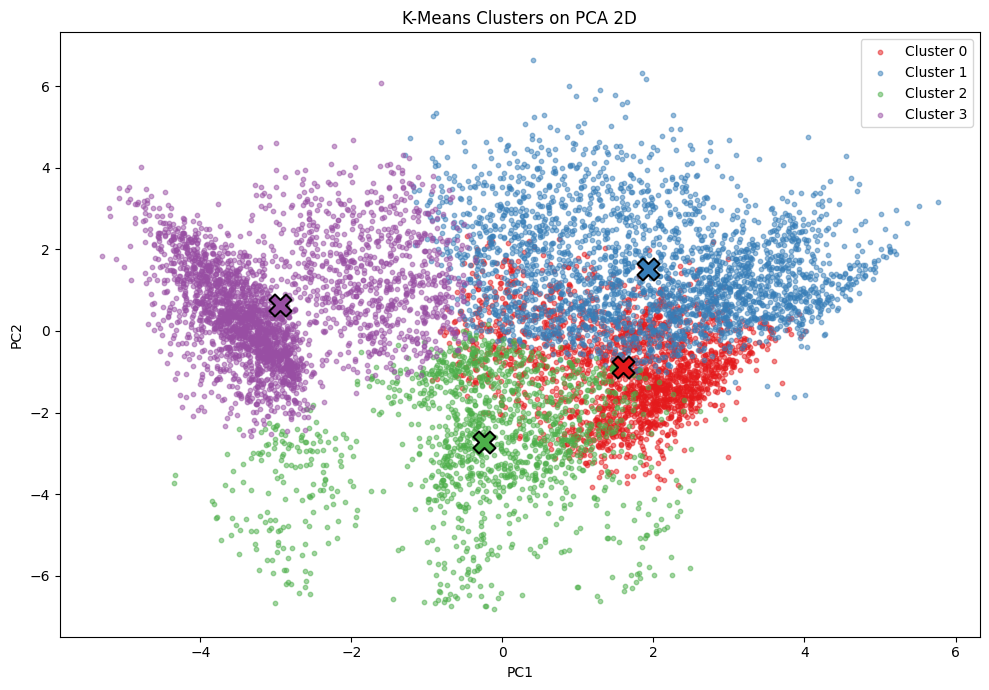

In [82]:
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(10, 7))
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']

for i in range(4):
    mask = df['Cluster'].values == i
    plt.scatter(df_pca_2d[mask, 0], df_pca_2d[mask, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.5, s=10)

# Plot centroids in 2D PCA space
for i in range(4):
    mask = df['Cluster'].values == i
    cx = df_pca_2d[mask, 0].mean()
    cy = df_pca_2d[mask, 1].mean()
    plt.scatter(cx, cy, c=colors[i], s=250, marker='X',
                edgecolors='black', linewidths=1.5, zorder=5)

plt.title('K-Means Clusters on PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

The good:

4 clusters are clearly visible and distinguishable
Cluster 3 (cyan, left) is the most well-separated and distinct
Cluster 1 (red, top-right) has a reasonably clear boundary
The clusters have logical spatial separation along PC1 and PC2

The concern:

Clusters 0 (blue) and 2 (pink) overlap significantly in the center — their boundaries are fuzzy
This overlap is expected though because we're viewing 7 dimensions compressed into 2 — some information is lost in this 2D view, so clusters that look overlapping here may actually be well-separated in the full 7D space

**K-means on all features**

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df_scaled)

df_original = df.copy()
print(df['Cluster'].value_counts().sort_index())

Cluster
0    2064
1    2770
2    1454
3    2661
Name: count, dtype: int64


**Almost the same as pca scaled**

**GMM**

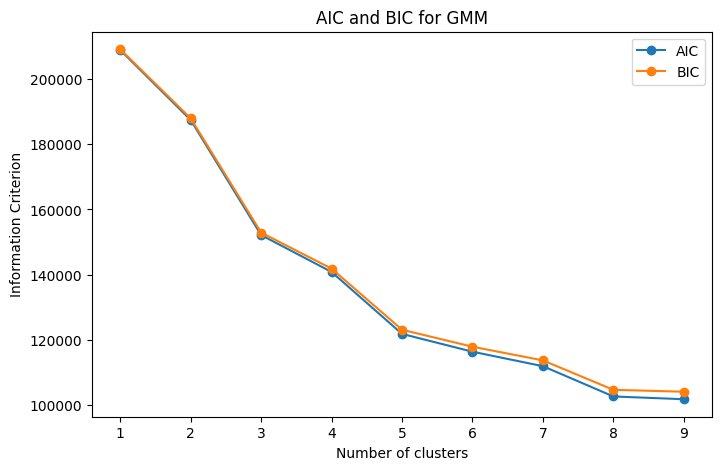

In [ ]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

n_components = range(1, 10)
aic_values = []
bic_values = []

for k in n_components:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(df_pca)  
    aic_values.append(gmm.aic(df_pca))
    bic_values.append(gmm.bic(df_pca))

plt.figure(figsize=(8,5))
plt.plot(n_components, aic_values, label='AIC', marker='o')
plt.plot(n_components, bic_values, label='BIC', marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Information Criterion')
plt.title('AIC and BIC for GMM')
plt.legend()
plt.show()

Overall trend:

Both AIC (blue) and BIC (orange) decrease as the number of clusters increases.

This means that adding more clusters improves the model fit, which is expected — more clusters = more flexibility.

Rate of decrease:

From 1 → 2 → 3 clusters, there’s a big drop. This suggests that 1 or 2 clusters are insufficient, and 3 clusters capture a lot more structure in the data.

After 3 clusters, the decrease becomes smaller and more gradual.

Elbow / diminishing returns:

Around 4–5 clusters, the curve starts to flatten.

This “flattening” is your elbow point, suggesting adding more clusters beyond 4–5 doesn’t improve the model significantly.

BIC vs AIC:

BIC penalizes complexity more than AIC → its minimum is slightly more conservative.

Here, BIC and AIC are very close, but BIC may suggest 4 clusters as a good balance between fit and simplicity.

AIC might slightly favor 5 or 6 clusters, but the improvement is small.